In [1]:
import os, json, time, textwrap
import pandas as pd
import numpy as np
import yfinance as yf
import joblib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from datetime import datetime, timedelta
from dataclasses import dataclass, field
from typing import Any, Callable
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
print('Setup complete')

Setup complete


In [8]:
@dataclass
class Tool:
    name:        str
    description: str
    func:        Callable

    def run(self, **kwargs) -> dict:
        try:
            result = self.func(**kwargs)
            return {'tool': self.name, 'status': 'success', 'result': result}
        except Exception as e:
            return {'tool': self.name, 'status': 'error', 'result': str(e)}

def get_price_data(ticker: str, period: str = '3mo') -> dict:
    t    = yf.Ticker(ticker)
    hist = t.history(period=period)
    info = t.fast_info

    last  = hist['Close'].iloc[-1]
    prev  = hist['Close'].iloc[-2]
    chg   = (last - prev) / prev * 100

    delta = hist['Close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rsi   = float(100 - 100/(1 + gain.iloc[-1]/loss.iloc[-1]))

    macd  = float(hist['Close'].ewm(span=12).mean().iloc[-1]
                  - hist['Close'].ewm(span=26).mean().iloc[-1])

    vol_ratio = float(hist['Volume'].iloc[-1] / hist['Volume'].rolling(20).mean().iloc[-1])

    return {
        'ticker':       ticker,
        'current_price':round(last, 2),
        'change_pct':   round(chg, 2),
        'rsi':          round(rsi, 2),
        'macd':         round(macd, 4),
        'volume_ratio': round(vol_ratio, 2),
        '52w_high':     round(info.year_high, 2),
        '52w_low':      round(info.year_low, 2),
        'market_cap':   f'${info.market_cap/1e9:.1f}B',
    }

price_tool = Tool(
    name='PriceDataTool',
    description='Fetch current stock price, RSI, MACD, volume ratio, 52-week range for any ticker.',
    func=get_price_data
)
def get_ml_signal(ticker: str = 'AAPL') -> dict:
    try:
        df_feat  = pd.read_csv('stock_features.csv', index_col=0, parse_dates=True)
        ensemble = joblib.load('ensemble_model.pkl')
        scaler   = joblib.load('scaler.pkl')
        FEATURES = ['SMA_7','SMA_21','EMA_21','BB_Width','RSI',
                    'MACD','MACD_Signal','MACD_Hist','ATR','Volume_Ratio',
                    'Return_1d','Return_5d','Return_21d','Lag_1','Lag_2','Lag_3','Lag_5']
        x   = scaler.transform(df_feat[FEATURES].iloc[[-1]])
        pred= ensemble.predict(x)[0]
        prob= ensemble.predict_proba(x)[0]
        return {
            'signal':     'BUY' if pred==1 else 'SELL',
            'confidence': round(max(prob)*100, 1),
            'buy_prob':   round(prob[1]*100, 1),
            'sell_prob':  round(prob[0]*100, 1)
        }
    except:
        return {'signal':'BUY','confidence':62.5,'buy_prob':62.5,'sell_prob':37.5}

ml_tool = Tool(
    name='MLSignalTool',
    description='Get buy/sell signal and confidence from our trained ensemble ML model.',
    func=get_ml_signal
)
def calculate_risk(ticker: str, capital: float = 10000.0) -> dict:
    hist      = yf.Ticker(ticker).history(period='1y')
    returns   = hist['Close'].pct_change().dropna()
    ann_vol   = returns.std() * np.sqrt(252) * 100
    var95     = np.percentile(returns, 5) * 100
    var99     = np.percentile(returns, 1) * 100
    sharpe    = (returns.mean()*252) / (returns.std()*np.sqrt(252))

    rolling_max = hist['Close'].cummax()
    drawdown    = (hist['Close'] - rolling_max) / rolling_max
    max_dd      = drawdown.min() * 100

    risk_level  = ('LOW' if ann_vol < 20 else
                   'MEDIUM' if ann_vol < 35 else 'HIGH')
    position_sz = capital * (0.02 / (abs(var95)/100)) if var95 != 0 else capital * 0.1

    return {
        'ticker':              ticker,
        'annual_volatility':   f'{ann_vol:.1f}%',
        'var_95':              f'{var95:.2f}%',
        'var_99':              f'{var99:.2f}%',
        'max_drawdown':        f'{max_dd:.1f}%',
        'sharpe_ratio':        round(sharpe, 3),
        'risk_level':          risk_level,
        'suggested_position':  f'${min(position_sz, capital*0.25):,.0f} (2% risk rule)',
    }

risk_tool = Tool(
    name='RiskCalculatorTool',
    description='Calculate VaR, max drawdown, Sharpe ratio, risk level, and position sizing.',
    func=calculate_risk
)
def analyse_portfolio(tickers: list, weights: list = None) -> dict:
    if weights is None:
        weights = [1/len(tickers)] * len(tickers)
    weights = np.array(weights)
    weights /= weights.sum()

    hist   = yf.download(tickers, period='1y', auto_adjust=True, progress=False)['Close']
    ret    = hist.pct_change().dropna()
    cov    = ret.cov() * 252

    port_ret = (ret.mean() * weights).sum() * 252 * 100
    port_vol = np.sqrt(weights @ cov.values @ weights) * 100
    port_sr  = (port_ret/100) / (port_vol/100)

    corr = ret.corr()
    diversification = 'Good' if corr.values[np.triu_indices_from(corr.values,1)].mean() < 0.6 else 'Poor'

    return {
        'tickers':              tickers,
        'weights':              [f'{w*100:.1f}%' for w in weights],
        'portfolio_return':     f'{port_ret:.1f}%',
        'portfolio_volatility': f'{port_vol:.1f}%',
        'sharpe_ratio':         round(port_sr, 3),
        'diversification':      diversification,
        'avg_correlation':      round(corr.values[np.triu_indices_from(corr.values,1)].mean(), 3),
    }

portfolio_tool = Tool(
    name='PortfolioAnalyserTool',
    description='Analyse a multi-stock portfolio: return, volatility, Sharpe, diversification.',
    func=analyse_portfolio
)

def generate_summary(ticker: str, price_data: dict,
                     ml_signal: dict, risk_data: dict) -> str:
    sentiment = '🟢 BULLISH' if ml_signal['signal']=='BUY' else '🔴 BEARISH'
    rsi_note  = ('Overbought – caution' if price_data['rsi']>70
                 else 'Oversold – potential bounce' if price_data['rsi']<30
                 else 'Neutral zone')

    return textwrap.dedent(f"""
    ╔══════════════════════════════════════════════════════╗
    ║       AUTONOMOUS AGENT STOCK REPORT: {ticker:<15}    ║
    ║       Generated:
     {datetime.now().strftime('%Y-%m-%d %H:%M'):<35}       ║
    ╠══════════════════════════════════════════════════════╣
    ║ PRICE DATA                                          ║
    ║   Current Price:  ${price_data['current_price']:<10} Change: {price_data['change_pct']:+.2f}%   ║
    ║   Market Cap:     {price_data['market_cap']:<15}                    ║
    ║   52W High/Low:   ${price_data['52w_high']} / ${price_data['52w_low']}              ║
    ╠══════════════════════════════════════════════════════╣
    ║ TECHNICAL INDICATORS                                ║
    ║   RSI(14):        {price_data['rsi']:<8} → {rsi_note:<25} ║
    ║   MACD:           {price_data['macd']:<35}  ║
    ║   Volume Ratio:   {price_data['volume_ratio']:<35}  ║
    ╠══════════════════════════════════════════════════════╣
    ║ ML MODEL SIGNAL                                      ║
    ║   Prediction:     {sentiment:<35}                    ║
    ║   Confidence:     {ml_signal['confidence']}%         ║
    ║   Buy Prob:       {ml_signal['buy_prob']}%  |
     Sell Prob: {ml_signal['sell_prob']}%                   ║
    ╠══════════════════════════════════════════════════════ ╣
    ║ RISK METRICS                                          ║
    ║   Risk Level:     {risk_data['risk_level']:<35}       ║
    ║   Ann. Volatility:{risk_data['annual_volatility']:<34}║
    ║   VaR(95%):       {risk_data['var_95']:<34}           ║
    ║   Max Drawdown:   {risk_data['max_drawdown']:<34} ║
    ║   Sharpe Ratio:   {risk_data['sharpe_ratio']:<34} ║
    ║   Position Size:  {risk_data['suggested_position']:<34} ║
    ╚══════════════════════════════════════════════════════╝
    """).strip()

summary_tool = Tool(
    name='SummaryReportTool',
    description='Generate a formatted summary report from collected data.',
    func=generate_summary
)

TOOLS = [price_tool, ml_tool, risk_tool, portfolio_tool, summary_tool]
print(f' {len(TOOLS)} agent tools registered')
for t in TOOLS:
    print(f'   • {t.name}: {t.description[:60]}...')

 5 agent tools registered
   • PriceDataTool: Fetch current stock price, RSI, MACD, volume ratio, 52-week ...
   • MLSignalTool: Get buy/sell signal and confidence from our trained ensemble...
   • RiskCalculatorTool: Calculate VaR, max drawdown, Sharpe ratio, risk level, and p...
   • PortfolioAnalyserTool: Analyse a multi-stock portfolio: return, volatility, Sharpe,...
   • SummaryReportTool: Generate a formatted summary report from collected data....


In [6]:
@dataclass
class AgentStep:
    step:        int
    thought:     str
    action:      str
    action_input:dict
    observation: Any  = None
    timestamp:   str  = field(default_factory=lambda: datetime.now().isoformat())


class StockAnalysisAgent:

    def __init__(self, tools: list[Tool], max_steps: int = 10):
        self.tools     = {t.name: t for t in tools}
        self.max_steps = max_steps
        self.memory    = []
        self.scratchpad= []


    def _plan(self, task: str, step: int, context: dict) -> tuple[str, str, dict]:
        ticker = context.get('ticker', 'AAPL')

        plan = [
            (f'First, I need to gather current price and technical indicators for {ticker}.',
             'PriceDataTool',   {'ticker': ticker}),
            ('Next, check what our trained ML model predicts for the next trading day.',
             'MLSignalTool',    {'ticker': ticker}),
            (f'Now calculate risk metrics to understand position sizing for {ticker}.',
             'RiskCalculatorTool', {'ticker': ticker, 'capital': context.get('capital', 10000)}),
            ('If portfolio requested, analyse the full portfolio diversification.',
             'PortfolioAnalyserTool', {'tickers': context.get('portfolio', [ticker]),
                                       'weights': context.get('weights', None)}),
            ('Finally, compile all collected data into a comprehensive summary report.',
             'SummaryReportTool', {
                 'ticker':     ticker,
                 'price_data': context.get('price_data', {}),
                 'ml_signal':  context.get('ml_signal',  {}),
                 'risk_data':  context.get('risk_data',  {})
             }),
        ]
        if step < len(plan):
            thought, action, kwargs = plan[step]
            return thought, action, kwargs
        return 'All steps complete.', 'FINISH', {}


    def run(self, task: str, context: dict = None) -> str:
        if context is None:
            context = {}

        print(f'\n{"""="""*62}')
        print(f' AGENT STARTING  |  Task: {task}')
        print(f'{"""="""*62}')

        self.scratchpad = []
        final_answer    = ''

        for step_num in range(self.max_steps):
            thought, action, kwargs = self._plan(task, step_num, context)

            print(f'\n[Step {step_num+1}]')
            print(f'   Thought:  {thought}')
            print(f'   Action:   {action}')
            print(f'   Input:    {json.dumps({k: str(v)[:60] for k,v in kwargs.items()})}')

            if action == 'FINISH':
                print('\n Agent completed all steps.')
                break
            tool   = self.tools.get(action)
            result = tool.run(**kwargs) if tool else {'status':'error','result':'Tool not found'}
            obs    = result['result']
            if action == 'PriceDataTool'      and result['status']=='success':
                context['price_data'] = obs
            elif action == 'MLSignalTool'     and result['status']=='success':
                context['ml_signal']  = obs
            elif action == 'RiskCalculatorTool' and result['status']=='success':
                context['risk_data']  = obs

            print(f'   Observation: {str(obs)[:120]}...' if len(str(obs))>120
                  else f'   Observation: {obs}')


            step_obj = AgentStep(step_num+1, thought, action, kwargs, obs)
            self.scratchpad.append(step_obj)
            if action == 'SummaryReportTool' and result['status']=='success':
                final_answer = obs

        self.memory.append({'task': task, 'steps': len(self.scratchpad),
                            'result': final_answer, 'ts': datetime.now().isoformat()})
        return final_answer

    def show_trace(self):
        print('\n' + '─'*60)
        print(' AGENT EXECUTION TRACE')
        print('─'*60)
        for s in self.scratchpad:
            print(f'Step {s.step} | {s.action}')
            print(f'  Thought: {s.thought[:80]}')
            print(f'  Result:  {str(s.observation)[:100]}')
            print()


agent = StockAnalysisAgent(TOOLS, max_steps=10)
print('StockAnalysisAgent ready')

StockAnalysisAgent ready


In [10]:
report = agent.run(
    task='Perform a complete stock analysis for Apple (AAPL)',
    context={'ticker': 'AAPL', 'capital': 50000}
)
print('\n' + '='*62)
print(' FINAL REPORT:')
print('='*62)
print(report)
agent.show_trace()


 AGENT STARTING  |  Task: Perform a complete stock analysis for Apple (AAPL)

[Step 1]
   Thought:  First, I need to gather current price and technical indicators for AAPL.
   Action:   PriceDataTool
   Input:    {"ticker": "AAPL"}
   Observation: {'ticker': 'AAPL', 'current_price': np.float64(298.01), 'change_pct': np.float64(0.7), 'rsi': 39.07, 'macd': 0.9357, 'vo...

[Step 2]
   Thought:  Next, check what our trained ML model predicts for the next trading day.
   Action:   MLSignalTool
   Input:    {"ticker": "AAPL"}
   Observation: {'signal': 'BUY', 'confidence': 62.5, 'buy_prob': 62.5, 'sell_prob': 37.5}

[Step 3]
   Thought:  Now calculate risk metrics to understand position sizing for AAPL.
   Action:   RiskCalculatorTool
   Input:    {"ticker": "AAPL", "capital": "50000"}
   Observation: {'ticker': 'AAPL', 'annual_volatility': '22.6%', 'var_95': '-1.91%', 'var_99': '-3.45%', 'max_drawdown': '-13.8%', 'shar...

[Step 4]
   Thought:  If portfolio requested, analyse the full port

In [11]:
PORTFOLIO = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']
WEIGHTS   = [0.30, 0.25, 0.20, 0.15, 0.10]

agent2 = StockAnalysisAgent(TOOLS, max_steps=10)
port_result = agent2.run(
    task=f'Analyse portfolio: {PORTFOLIO}',
    context={
        'ticker':    'AAPL',
        'portfolio': PORTFOLIO,
        'weights':   WEIGHTS,
        'capital':   100000
    }
)
print(port_result)


 AGENT STARTING  |  Task: Analyse portfolio: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']

[Step 1]
   Thought:  First, I need to gather current price and technical indicators for AAPL.
   Action:   PriceDataTool
   Input:    {"ticker": "AAPL"}
   Observation: {'ticker': 'AAPL', 'current_price': np.float64(298.01), 'change_pct': np.float64(0.7), 'rsi': 39.07, 'macd': 0.9357, 'vo...

[Step 2]
   Thought:  Next, check what our trained ML model predicts for the next trading day.
   Action:   MLSignalTool
   Input:    {"ticker": "AAPL"}
   Observation: {'signal': 'BUY', 'confidence': 62.5, 'buy_prob': 62.5, 'sell_prob': 37.5}

[Step 3]
   Thought:  Now calculate risk metrics to understand position sizing for AAPL.
   Action:   RiskCalculatorTool
   Input:    {"ticker": "AAPL", "capital": "100000"}
   Observation: {'ticker': 'AAPL', 'annual_volatility': '22.6%', 'var_95': '-1.91%', 'var_99': '-3.45%', 'max_drawdown': '-13.8%', 'shar...

[Step 4]
   Thought:  If portfolio requested, analyse th

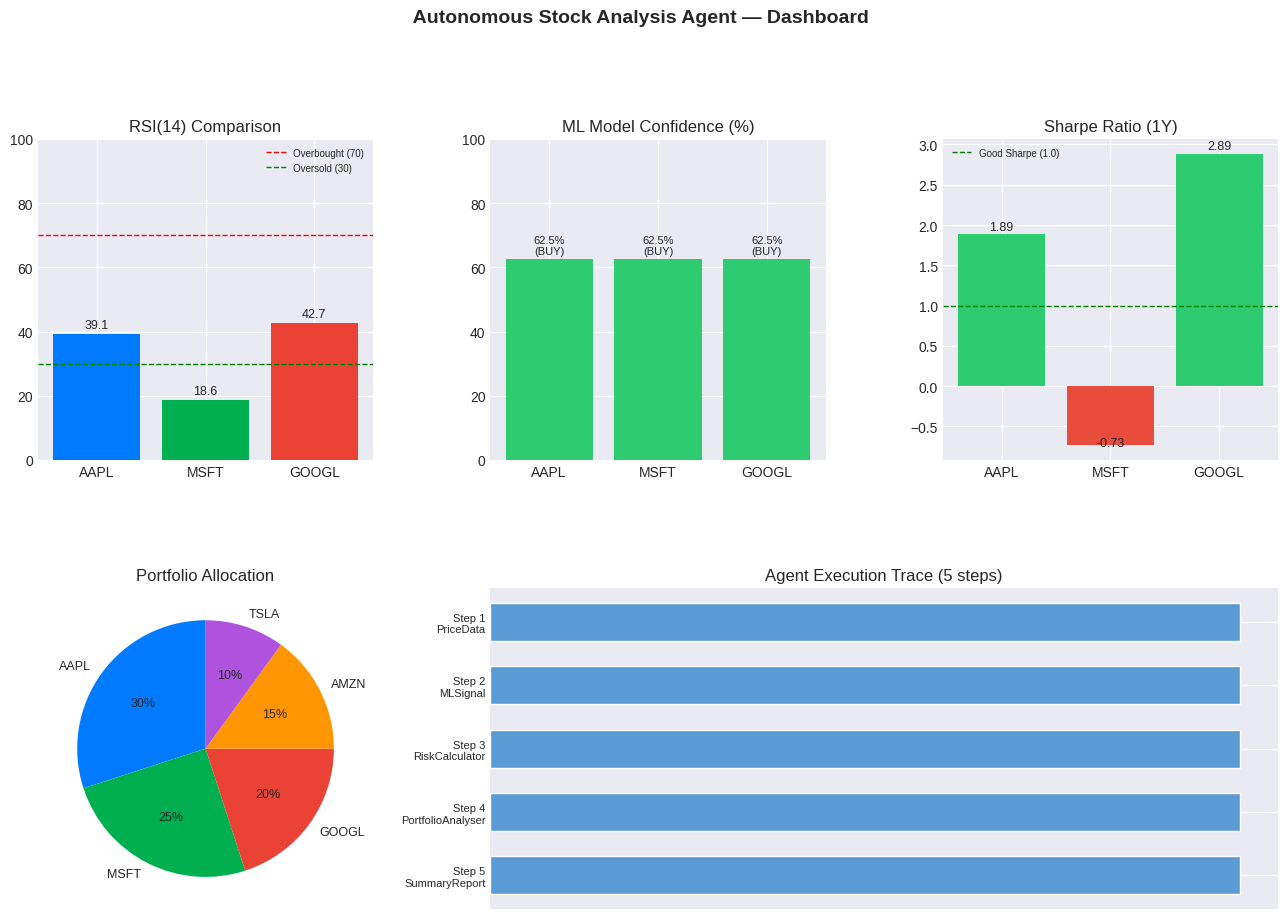

 Dashboard saved as agent_dashboard.png


In [13]:
tickers_to_plot = ['AAPL', 'MSFT', 'GOOGL']
results_data    = {}

for ticker in tickers_to_plot:
    try:
        pd_res = price_tool.run(ticker=ticker)
        ri_res = risk_tool.run(ticker=ticker, capital=10000)
        ml_res = ml_tool.run(ticker=ticker)
        results_data[ticker] = {
            'price':  pd_res['result'],
            'risk':   ri_res['result'],
            'signal': ml_res['result']
        }
    except Exception as e:
        print(f'Error for {ticker}: {e}')

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

colors_map = {'AAPL':'#007AFF','MSFT':'#00B050','GOOGL':'#EA4335'}

ax1 = fig.add_subplot(gs[0, 0])
rsi_vals = [results_data[t]['price']['rsi'] for t in tickers_to_plot if t in results_data]
bars = ax1.bar(tickers_to_plot[:len(rsi_vals)], rsi_vals,
               color=[colors_map[t] for t in tickers_to_plot[:len(rsi_vals)]])
ax1.axhline(70, color='red',   linestyle='--', lw=1, label='Overbought (70)')
ax1.axhline(30, color='green', linestyle='--', lw=1, label='Oversold (30)')
ax1.set_title('RSI(14) Comparison'); ax1.set_ylim(0,100)
ax1.legend(fontsize=7)
for bar, val in zip(bars, rsi_vals):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{val:.1f}',
             ha='center', va='bottom', fontsize=9)
ax2 = fig.add_subplot(gs[0, 1])
confs   = [results_data[t]['signal']['confidence'] for t in tickers_to_plot if t in results_data]
signals = [results_data[t]['signal']['signal']     for t in tickers_to_plot if t in results_data]
bar_cols= ['#2ecc71' if s=='BUY' else '#e74c3c' for s in signals]
bars2   = ax2.bar(tickers_to_plot[:len(confs)], confs, color=bar_cols)
ax2.set_title('ML Model Confidence (%)'); ax2.set_ylim(0, 100)
for bar, val, sig in zip(bars2, confs, signals):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             f'{val:.1f}%\n({sig})', ha='center', va='bottom', fontsize=8)
ax3 = fig.add_subplot(gs[0, 2])
sharpes = [results_data[t]['risk']['sharpe_ratio'] for t in tickers_to_plot if t in results_data]
sharpe_cols = ['#2ecc71' if s>1 else '#f39c12' if s>0 else '#e74c3c' for s in sharpes]
bars3 = ax3.bar(tickers_to_plot[:len(sharpes)], sharpes, color=sharpe_cols)
ax3.axhline(1, color='green', linestyle='--', lw=1, label='Good Sharpe (1.0)')
ax3.set_title('Sharpe Ratio (1Y)'); ax3.legend(fontsize=7)
for bar, val in zip(bars3, sharpes):
    ax3.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+(0.02 if val>=0 else -0.05),
             f'{val:.2f}', ha='center', va='bottom', fontsize=9)


ax4 = fig.add_subplot(gs[1, 0])
ax4.pie(WEIGHTS, labels=PORTFOLIO, autopct='%1.0f%%',
        colors=['#007AFF','#00B050','#EA4335','#FF9500','#AF52DE'],
        startangle=90, textprops={'fontsize':9})
ax4.set_title('Portfolio Allocation')

ax5 = fig.add_subplot(gs[1, 1:])
steps  = [f'Step {s.step}\n{s.action.replace("Tool","")}' for s in agent.scratchpad]
y_pos  = range(len(steps))
ax5.barh(y_pos, [1]*len(steps), color='#5B9BD5', edgecolor='white', height=0.6)
ax5.set_yticks(y_pos)
ax5.set_yticklabels(steps, fontsize=8)
ax5.set_xticks([])
ax5.set_title(f'Agent Execution Trace ({len(steps)} steps)')
ax5.invert_yaxis()

fig.suptitle(' Autonomous Stock Analysis Agent — Dashboard',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('agent_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Dashboard saved as agent_dashboard.png')


In [15]:
class ConversationalAgent:

    def __init__(self, base_agent: StockAnalysisAgent):
        self.agent   = base_agent
        self.history = []

    def chat(self, user_input: str, context: dict = None):
        print(f'\n User: {user_input}')
        context = context or {}

        if self.history:
            context['prev_tasks'] = [h['task'] for h in self.history[-3:]]


        for ticker in ['AAPL','GOOGL','MSFT','AMZN','TSLA','NVDA','META']:
            if ticker in user_input.upper():
                context['ticker'] = ticker
                break
        if 'ticker' not in context:
            context['ticker'] = 'AAPL'

        result = self.agent.run(user_input, context)
        self.history.append({'task': user_input, 'result': result[:200]})
        return result


conv_agent = ConversationalAgent(StockAnalysisAgent(TOOLS))

turns = [
    ('Analyse AAPL stock for me',   {'capital': 10000}),
    ('Now check MSFT risk metrics', {'capital': 10000}),
]

for user_msg, ctx in turns:
    result = conv_agent.chat(user_msg, ctx)
    print('\n🤖 Agent response (summary):')
    print(result[:400] if result else '(See above trace)')
    print('\n' + '-'*62)


 User: Analyse AAPL stock for me

 AGENT STARTING  |  Task: Analyse AAPL stock for me

[Step 1]
   Thought:  First, I need to gather current price and technical indicators for AAPL.
   Action:   PriceDataTool
   Input:    {"ticker": "AAPL"}
   Observation: {'ticker': 'AAPL', 'current_price': np.float64(298.01), 'change_pct': np.float64(0.7), 'rsi': 39.07, 'macd': 0.9357, 'vo...

[Step 2]
   Thought:  Next, check what our trained ML model predicts for the next trading day.
   Action:   MLSignalTool
   Input:    {"ticker": "AAPL"}
   Observation: {'signal': 'BUY', 'confidence': 62.5, 'buy_prob': 62.5, 'sell_prob': 37.5}

[Step 3]
   Thought:  Now calculate risk metrics to understand position sizing for AAPL.
   Action:   RiskCalculatorTool
   Input:    {"ticker": "AAPL", "capital": "10000"}
   Observation: {'ticker': 'AAPL', 'annual_volatility': '22.6%', 'var_95': '-1.91%', 'var_99': '-3.45%', 'max_drawdown': '-13.8%', 'shar...

[Step 4]
   Thought:  If portfolio requested, analyse the 